In [1]:
import kaleido
kaleido.get_chrome_sync()
import os
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import polars as pl
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from collections import defaultdict
from functools import reduce
from matplotlib_venn import venn2
from scipy.stats import linregress


In [55]:
markers = ["Dad2", "Sac6", "Tgl3", "Pex3", "Pil1", "Nuf2", "Snf7", "Sec21", "Sec7", "Psr1", "Spf1", "Om45"]
label_maps = {
    "Dad2": "Spindle Pole Bodies", 
    "Sac6": "Actin Patches",
    "Tgl3": "Lipid Droplets",
    "Pex3": "Peroxisomes",
    "Pil1": "Eisosomes",
    "Nuf2": "Kinetochores",
    "Snf7": "Endosomes",
    "Sec21": "Golgi (Early)",
    "Sec7": "Golgi (Late)",
    "Psr1": "Plasma Membrane",
    "Spf1": "Endoplasmic Reticulum",
    "Om45": "Mitochondria"
}

label_maps_abv = {
    "Dad2": "SPBs", 
    "Sac6": "APs",
    "Tgl3": "LDs",
    "Pex3": "Peroxisomes",
    "Pil1": "Eisosomes",
    "Nuf2": "Kinetochores",
    "Snf7": "Endosomes",
    "Sec21": "Golgi \n(Early)",
    "Sec7": "Golgi \n(Late)",
    "Psr1": "PM",
    "Spf1": "ER",
    "Om45": "Mitochondria"
}
phenotype_set = "Compartments" # Cells or Compartments
pen_col_to_select = "Overall_Penetrance"

### Comparing Hits Between MPv1 and MPv2

In [ ]:
def blend(c1,c2, darken=0.85):
    rgb = (
        np.array(mcolors.to_rgb(c1)) +
        np.array(mcolors.to_rgb(c2))
    ) / 2
    return rgb * darken

hit_dfs = []
for marker in markers:
    compartment_hits = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/Compartments/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(pl.lit(marker).alias("Marker"))
        .select(["Marker", "Strain_ID"])
        )
    
    cell_hits = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/Cells/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(pl.lit(marker).alias("Marker"))
        .select(["Marker", "Strain_ID"])
        )
    
    overall_hits = (
        pl
        .concat([compartment_hits, cell_hits], how="vertical")
        .unique()
    )
    
    hit_dfs.append(overall_hits)
    
mpv2_hits = (
    pl
    .concat(hit_dfs, how="vertical")
    .group_by("Marker")
    .agg(pl.col("Strain_ID").unique())
    .to_dict(as_series=False)
    )
mpv1_hits = (
    pl
    .read_csv("/mnt/c/Users/peree/OneDrive/Desktop/CompBio_Code/penetrance_pleiotropy_replicate_analysis/penetrance_data/aggregated_data/sheetE.csv")
    .select(["Marker", "Strain"])
    .rename({"Strain": "Strain_ID"})
    .filter(pl.col("Marker").is_in(markers))
    .group_by("Marker")
    .agg(pl.col("Strain_ID").unique())
    .to_dict(as_series=False)
    )

mpv2_dict = dict(zip(mpv2_hits["Marker"], mpv2_hits["Strain_ID"]))
mpv1_dict = dict(zip(mpv1_hits["Marker"], mpv1_hits["Strain_ID"]))

mpv2_dict = {k: set(v) for k, v in mpv2_dict.items()}
mpv1_dict = {k: set(v) for k, v in mpv1_dict.items()}

markers = sorted(set(mpv1_dict) | set(mpv2_dict))


# Plot
c1 = "#093D5F"
c2 = "#A31E23"

fig, axes = plt.subplots(4, 3, figsize=(6, 8))
axes = axes.flatten()

for i, marker in enumerate(markers):
    set1 = mpv1_dict.get(marker, set())
    set2 = mpv2_dict.get(marker, set())

    v = venn2([set1, set2], set_labels=("MPv1", "MPv2"), ax=axes[i])
    axes[i].set_title(f"{label_maps[marker]}")
    
    # Recolour
    v.get_patch_by_id('10').set_color(c1)
    v.get_patch_by_id('01').set_color(c2)
    v.get_patch_by_id('11').set_color(blend(c1,c2))
    
    for region in ['10','01','11']:
        patch = v.get_patch_by_id(region)
        label = v.get_label_by_id(region)
        if patch:
            patch.set_alpha(0.75)
            label.set_color("white")

# Hide unused subplot (since 5 plots in 2x3 grid)
for j in range(len(markers), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/venns.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()

### Overlap in Cell and SC Hits for MPv2

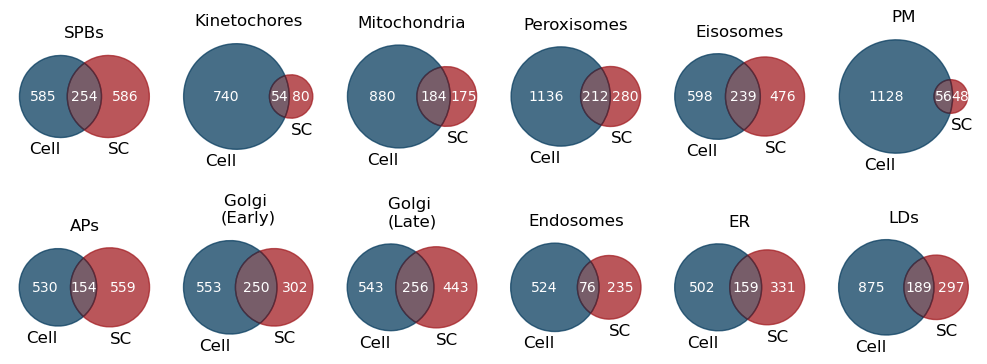

In [12]:
def blend(c1,c2, darken=0.85):
    rgb = (
        np.array(mcolors.to_rgb(c1)) +
        np.array(mcolors.to_rgb(c2))
    ) / 2
    return rgb * darken

cell_hits = []
compartment_hits = []
for marker in markers:
    cell_hits_marker = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/Cells/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(pl.lit(marker).alias("Marker"))
        .select(["Marker", "Strain_ID"])
        )
    
    compartment_hits_marker = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/Compartments/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(pl.lit(marker).alias("Marker"))
        .select(["Marker", "Strain_ID"])
        )
    
    cell_hits.append(cell_hits_marker)
    compartment_hits.append(compartment_hits_marker)
    
combined_cell_hits = (
    pl
    .concat(cell_hits, how="vertical")
    .group_by("Marker")
    .agg(pl.col("Strain_ID").unique())
    .to_dict(as_series=False)
    )

combined_compartment_hits = (
    pl
    .concat(compartment_hits, how="vertical")
    .group_by("Marker")
    .agg(pl.col("Strain_ID").unique())
    .to_dict(as_series=False)
    )

cell_dict = dict(zip(combined_cell_hits["Marker"], combined_cell_hits["Strain_ID"]))
compartment_dict = dict(zip(combined_compartment_hits["Marker"], combined_compartment_hits["Strain_ID"]))

cell_dict = {k: set(v) for k, v in cell_dict.items()}
compartment_dict = {k: set(v) for k, v in compartment_dict.items()}

markers = sorted(set(cell_dict) | set(compartment_dict))


# Plot
c1 = "#093D5F"
c2 = "#A31E23"

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
axes = axes.flatten()

for i, marker in enumerate(markers):
    set1 = cell_dict.get(marker, set())
    set2 = compartment_dict.get(marker, set())

    v = venn2([set1, set2], set_labels=("Cell", "SC"), ax=axes[i])
    axes[i].set_title(f"{label_maps_abv[marker]}")
    
    # Recolour
    v.get_patch_by_id('10').set_color(c1)
    v.get_patch_by_id('01').set_color(c2)
    v.get_patch_by_id('11').set_color(blend(c1,c2))
    
    for region in ['10','01','11']:
        patch = v.get_patch_by_id(region)
        label = v.get_label_by_id(region)
        if patch:
            patch.set_alpha(0.75)
            label.set_color("white")

# Hide unused subplot (since 5 plots in 2x3 grid)
for j in range(len(markers), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/venns_cell_sc.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()

### Correlation Matrix

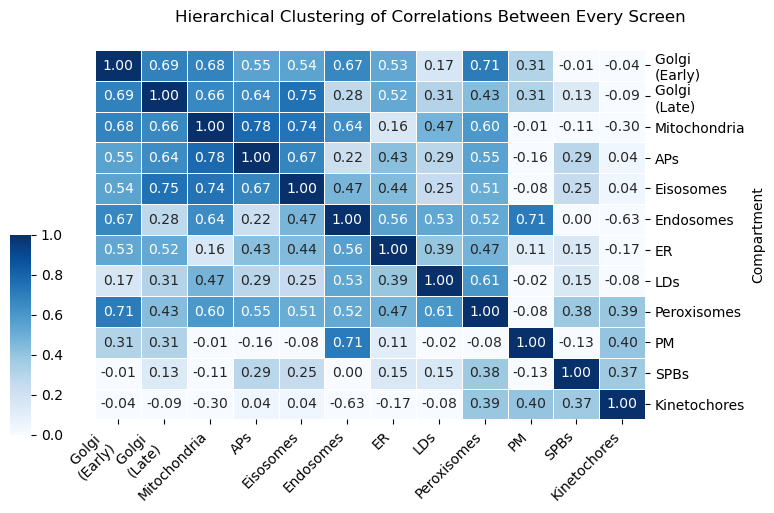

In [16]:
## Read data
marker_dfs = []
for marker in markers:
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .select(["ORF", "Strain_ID"] + [pen_col_to_select])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        .rename({pen_col_to_select: marker})
        .drop("ORF")
        )
    marker_dfs.append(marker_df)

combined_df = marker_dfs[0]
for marker_df in marker_dfs[1:]:
    combined_df = combined_df.join(
        marker_df,
        on="Strain_ID",
        how="full",
        coalesce=True
    )


## Calculate correlations
numeric_df = combined_df.drop("Strain_ID").rename(label_maps_abv)
corr_matrix = pl.DataFrame(
    {
        col1: [
            numeric_df.select(pl.corr(pl.col(col1), pl.col(col2))).item()
            for col2 in numeric_df.columns
        ]
        for col1 in numeric_df.columns
    }
)

corr_matrix = (
    corr_matrix
    .with_columns(pl.Series("Compartment", numeric_df.columns))
    .select(["Compartment"] + numeric_df.columns)
    .to_pandas()
    )

corr_matrix = corr_matrix.set_index("Compartment")


## Plot
g = sns.clustermap(
    corr_matrix, 
    figsize=(7, 5),
    method='ward', # single, complete, average, weighted, centroid, median, ward
    vmin=0, 
    vmax=1, 
    dendrogram_ratio=(0.0001, 0.0001), # effectively hide dendrograms
    cbar_pos=(-0.1, .2, .03, .4), 
    annot=True, 
    cmap="Blues", 
    fmt=".2f", 
    linewidths=0.5)

plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right"
)

g.figure.suptitle("Hierarchical Clustering of Correlations Between Every Screen", y=1.05)
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/marker_correlations.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()


### Number of Genes Causing/Not Causing Defects

In [15]:
all_screened_genes = []
genes_causing_defects = []

for marker in markers:
    sheetB_ORFs =  (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetB")
        .with_columns(
            (
                pl
                .when(pl.col("Strain_ID").str.contains("tsa"))
                .then(pl.lit("Essential"))
                .otherwise(pl.lit("Nonessential"))
                ).alias("Essentiality")
            )
        .select(["ORF", "Essentiality"])
    )
    all_screened_genes.append(sheetB_ORFs)
    
    sheetD_ORFs =  (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (
                pl
                .when(pl.col("Strain_ID").str.contains("tsa"))
                .then(pl.lit("Essential"))
                .otherwise(pl.lit("Nonessential"))
                ).alias("Essentiality")
            )
        .select(["ORF", "Essentiality"])
    )
    genes_causing_defects.append(sheetD_ORFs)

all_screened_genes = pl.concat(all_screened_genes, how="vertical").unique()
genes_causing_defects = pl.concat(genes_causing_defects, how="vertical").unique()
genes_not_causing_defects = all_screened_genes.filter(~pl.col("ORF").is_in(genes_causing_defects["ORF"]))

num_genes_causing_defects = genes_causing_defects.shape[0]
num_genes_not_causing_defects = genes_not_causing_defects.shape[0]

num_nonessential_genes_causing_defects = genes_causing_defects.filter(pl.col("Essentiality") == "Nonessential").shape[0]
num_nonessential_genes_not_causing_defects = genes_not_causing_defects.filter(pl.col("Essentiality") == "Nonessential").shape[0]

num_essential_genes_causing_defects = genes_causing_defects.filter(pl.col("Essentiality") == "Essential").shape[0]
num_essential_genes_not_causing_defects = genes_not_causing_defects.filter(pl.col("Essentiality") == "Essential").shape[0]

print(
    f"""
    Genes Causing Defects: {num_genes_causing_defects} ({(num_genes_causing_defects / all_screened_genes.shape[0]) * 100}%)
    Genes Not Causing Defects: {num_genes_not_causing_defects} ({(num_genes_not_causing_defects / all_screened_genes.shape[0]) * 100}%)
    Nonessential Genes Causing Defects: {num_nonessential_genes_causing_defects} ({num_nonessential_genes_causing_defects / all_screened_genes.filter(pl.col("Essentiality") == "Nonessential").shape[0] * 100}%)
    Essential Genes Causing Defects: {num_essential_genes_causing_defects} ({num_essential_genes_causing_defects / all_screened_genes.filter(pl.col("Essentiality") == "Essential").shape[0] * 100}%)
    Nonessential Genes Not Causing Defects: {num_nonessential_genes_not_causing_defects} ({num_nonessential_genes_not_causing_defects / all_screened_genes.filter(pl.col("Essentiality") == "Nonessential").shape[0] * 100}%)
    Essential Genes Not Causing Defects: {num_essential_genes_not_causing_defects} ({num_essential_genes_not_causing_defects / all_screened_genes.filter(pl.col("Essentiality") == "Essential").shape[0] * 100}%)
    """
)

fig = go.Figure(go.Parcats(
    dimensions=[
        {'label': '',
         'values': ['Defect', 'Defect', 
                    'No Defect', 'No Defect']},
        {'label': '',
         'values': ['Nonessential', 'Essential',
                    'Nonessential', 'Essential']
         }
        ],
    counts=[num_nonessential_genes_causing_defects, num_essential_genes_causing_defects, num_nonessential_genes_not_causing_defects, num_essential_genes_not_causing_defects],
    line=dict(
        shape='hspline',
        color=[0,0,1,1],
        colorscale=[[0,"steelblue"],[1,"lightgray"]]
        )
))

fig.update_layout(
    width=500,
    height=500
)

fig.write_image("/mnt/c/Users/peree/OneDrive/Desktop/parcats_plot.pdf")

fig.show()


/tmp/ipykernel_15832/2858960264.py:37: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  genes_not_causing_defects = all_screened_genes.filter(~pl.col("ORF").is_in(genes_causing_defects["ORF"]))



    Genes Causing Defects: 2547 (56.17556241729158%)
    Genes Not Causing Defects: 1984 (43.75827084252315%)
    Nonessential Genes Causing Defects: 2006 (52.00933367902515%)
    Essential Genes Causing Defects: 541 (79.91137370753324%)
    Nonessential Genes Not Causing Defects: 1848 (47.91288566243194%)
    Essential Genes Not Causing Defects: 136 (20.088626292466767%)
    


### Penetrance Distributions (Density)

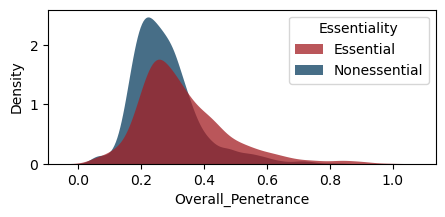

In [17]:
genes_causing_defects = []

for marker in markers:
    sheetD_ORFs =  (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (
                pl
                .when(pl.col("Strain_ID").str.contains("tsa"))
                .then(pl.lit("Essential"))
                .otherwise(pl.lit("Nonessential"))
                ).alias("Essentiality")
            )
        .select(["Essentiality", "Overall_Penetrance"])
    )
    genes_causing_defects.append(sheetD_ORFs)

genes_causing_defects = (
    pl
    .concat(genes_causing_defects, how="vertical")
    #.filter(pl.col("Overall_Penetrance") >= 0.1)
    .to_pandas()
    )

plt.figure(figsize=(5,2))
sns.kdeplot(
    data = genes_causing_defects, 
    x = "Overall_Penetrance", 
    hue = "Essentiality", 
    linewidth = 0, 
    fill = True, 
    alpha=0.75,
    palette={"Nonessential": "#093D5F",
             "Essential": "#A31E23"},
    legend = True)

plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/penetrance_density.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()


### Penetrance Distributions

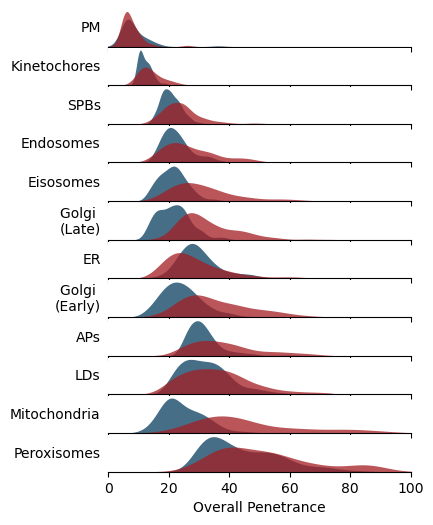

In [18]:
## Read data
marker_dfs = []
for marker in markers:
    #renamed_marker = {col: f"{marker}_{col}" for col in pen_cols_to_select}
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (pl.lit(marker).alias("Marker")),
            (
                pl
                .when(pl.col("Strain_ID").str.contains("tsa"))
                .then(pl.lit("Essential"))
                .otherwise(pl.lit("Nonessential"))
            ).alias("Essentiality"),
            (pl.col("Overall_Penetrance") * 100)
            )
        .select(["Marker", "ORF", "Strain_ID", "Essentiality"] + [pen_col_to_select])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        .drop("ORF")
        )
    marker_dfs.append(marker_df)

combined_df = pl.concat(marker_dfs, how="vertical")

markers_order = (
    combined_df
    .group_by(["Marker"])
    .agg(pl.col("Overall_Penetrance").median().alias("Median_Penetrance"))
    .sort("Median_Penetrance", descending=False)
)["Marker"].to_list()

df = combined_df.to_pandas()

# --- figure with 2 columns: labels | plots ---
fig = plt.figure(figsize=(4, 6))
gs = gridspec.GridSpec(
    nrows=len(markers_order),
    ncols=2,
    width_ratios=[0, 1],   # label column is narrow
    hspace=0.05,
    wspace=0.05
)

axes_plot = []

for i, marker in enumerate(markers_order):

    sub = df[df.Marker == marker]

    # --- label axis (left column) ---
    ax_label = fig.add_subplot(gs[i, 0])
    ax_label.text(
        1, 0.5,
        label_maps_abv.get(marker, marker),
        ha="right",
        va="center"
    )
    ax_label.axis("off")

    # --- plot axis (right column) ---
    ax = fig.add_subplot(gs[i, 1], sharex=axes_plot[0] if axes_plot else None)

    sns.kdeplot(
        data=sub[sub.Essentiality == "Nonessential"],
        x="Overall_Penetrance",
        fill=True,
        linewidth=0,
        alpha=0.75,
        color="#093D5F",
        ax=ax
    )

    sns.kdeplot(
        data=sub[sub.Essentiality == "Essential"],
        x="Overall_Penetrance",
        fill=True,
        linewidth=0,
        alpha=0.75,
        color="#A31E23",
        ax=ax
    )

    # clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # only bottom spine on last plot
    if i != len(markers_order) - 1:
        ax.tick_params(axis="x", labelbottom=False)

    ax.set_yticks([])
    ax.set_ylabel("")

    axes_plot.append(ax)

# shared x formatting
axes_plot[-1].set_xlim(0, 100)
axes_plot[-1].set_xlabel("Overall Penetrance")
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/penetrance_distributions.pdf", bbox_inches="tight")
plt.show()
plt.close()

### Replicate - Replicate Correlations

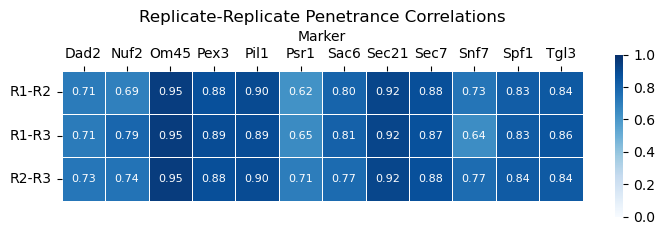

In [19]:
corr_matrices = []

for marker in markers:
    ## Read data
    #renamed_marker = {col: f"{marker}_{col}" for col in pen_cols_to_select}
    sheetD_strains = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .select("Strain_ID", "ORF")
        .drop("ORF")
        .to_series()
        .to_list()
        )
    
    marker_df = (
        pl
        .read_csv(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/per_replicate_penentrances_and_distances/{marker}_per_replicate_penetrances_and_distances.csv")
        .select(["ORF", "Strain_ID", "Penetrance_R1", "Penetrance_R2", "Penetrance_R3"])
        .filter(pl.col("Strain_ID").is_in(sheetD_strains))
        .rename({
            "Penetrance_R1": f"{marker}_R1",
            "Penetrance_R2": f"{marker}_R2",
            "Penetrance_R3": f"{marker}_R3",
            })
        .drop("ORF")
        )


    ## Calculate correlations
    numeric_df = marker_df.drop("Strain_ID")
    corr_matrix = pl.DataFrame(
        {
            col1: [
                numeric_df.select(pl.corr(pl.col(col1), pl.col(col2))).item()
                for col2 in numeric_df.columns
            ]
            for col1 in numeric_df.columns
        }
    )

    corr_matrix = (
        corr_matrix
        .with_columns(pl.Series("Marker", numeric_df.columns))
        .select(["Marker"] + numeric_df.columns)
        )
    
    corr_matrix_flat = (
        pl.DataFrame(
            {
                "Marker": marker,
                "R1-R2": corr_matrix[1,1],
                "R1-R3": corr_matrix[2,1],
                "R2-R3": corr_matrix[2,2]
                }
            )
        )

    corr_matrices.append(corr_matrix_flat)
    
corr_matrices = (
    pl
    .concat(corr_matrices, how="vertical")
    .sort("Marker")
    .to_pandas()
    .set_index("Marker")
    )

## Plot
nrows, ncols = corr_matrices.T.shape
plt.figure(figsize=(0.7*ncols, 0.7*nrows))
ax = sns.heatmap(
    corr_matrices.T, 
    vmin=0, 
    vmax=1, 
    annot=True, 
    annot_kws={"size":8},
    cmap="Blues", 
    fmt=".2f", 
    linewidths=0.5,
    square=True)

plt.xticks(rotation=45, ha="left")
plt.yticks(rotation=0, ha="right")

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

plt.title("Replicate-Replicate Penetrance Correlations")
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/replicate_correlations.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()

### Morphological Pleiotropy

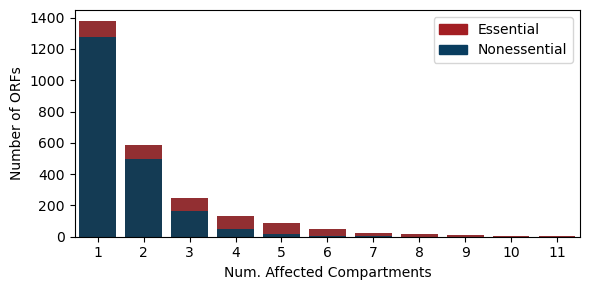

In [20]:
## Read data
marker_dfs = []
for marker in markers:
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (pl.lit(marker).alias("Marker")),
            (
                pl
                .when(pl.col("Strain_ID").str.contains("tsa"))
                .then(pl.lit("Essential"))
                .otherwise(pl.lit("Nonessential"))
            ).alias("Essentiality")
            )
        .select(["Marker", "ORF", "Essentiality"])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        )
    marker_dfs.append(marker_df)

combined_df = pl.concat(marker_dfs, how="vertical").unique()

combined_df_all = (
    combined_df
    .group_by(["ORF", "Essentiality"])
    .agg(pl.len().alias("Num_Comps"))
    .group_by("Num_Comps")
    .agg(pl.len().alias("Num_ORFs"))
)

combined_df_noness = (
    combined_df
    .filter(pl.col("Essentiality") == "Nonessential")
    .group_by("ORF")
    .agg(pl.len().alias("Num_Comps"))
    .group_by("Num_Comps")
    .agg(pl.len().alias("Num_ORFs"))
)


# Plot
fig, ax = plt.subplots(figsize=(6, 3))

bar1 = sns.barplot(
    x="Num_Comps",
    y="Num_ORFs",
    data=combined_df_all,
    color="#A31E23",
    ax=ax
)

bar2 = sns.barplot(
    x="Num_Comps",
    y="Num_ORFs",
    data=combined_df_noness,
    estimator=sum,
    color="#093D5F",
    ax=ax
)

# axis labels (rename axes)
ax.set_xlabel("Num. Affected Compartments")
ax.set_ylabel("Number of ORFs")

# legend
top_bar = mpatches.Patch(color="#A31E23", label="Essential")
bottom_bar = mpatches.Patch(color="#093D5F", label="Nonessential")

ax.legend(handles=[top_bar, bottom_bar])

plt.tight_layout()
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/pleiotropy.pdf", format="pdf",  bbox_inches="tight")
plt.show()

### Pleiotropy vs. Penetrance

/tmp/ipykernel_15832/1732214273.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


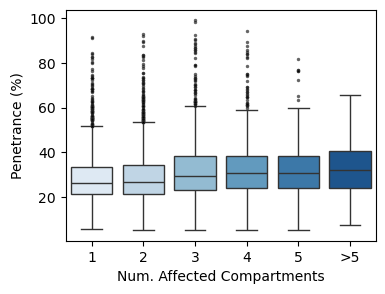

In [21]:
## Read data
marker_dfs = []
for marker in markers:
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (pl.lit(marker).alias("Marker")),
            (pl.col("Overall_Penetrance") * 100)
            )
        .select(["Marker", "ORF", "Strain_ID", "Overall_Penetrance"])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        )
    marker_dfs.append(marker_df)

combined_df = pl.concat(marker_dfs, how="vertical")

combined_df_plei = (
    combined_df
    .drop("Overall_Penetrance")
    .unique()
    .group_by(["Strain_ID"])
    .agg(pl.len().alias("Num_Comps"))
    .with_columns(
        (
            pl
            .when(pl.col("Num_Comps") > 5)
            .then(6)
            .otherwise(pl.col("Num_Comps"))
        ).alias("Num_Comps")
    )
)

combined_df = (
    combined_df
    .join(combined_df_plei, on="Strain_ID")
    )

# Plot
fig, ax = plt.subplots(figsize=(4, 3))

flierprops = dict(
    marker='o',
    markersize=2,
    markerfacecolor='black',
    markeredgewidth=0.5,
    alpha=0.6
)

sns.boxplot(x="Num_Comps", y="Overall_Penetrance",
            hue="Num_Comps",
            palette=sns.color_palette("Blues", as_cmap=False),
            data=combined_df,
            legend=False,
            flierprops=flierprops)

# axis labels (rename axes)
ax.set_xticklabels([
    ">5" if tick.get_text() == "6" else tick.get_text()
    for tick in ax.get_xticklabels()
])

ax.set_xlabel("Num. Affected Compartments")
ax.set_ylabel("Penetrance (%)")

plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/pleipen.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()

### Pleiotropy vs. Fitness

/tmp/ipykernel_15832/1099797265.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


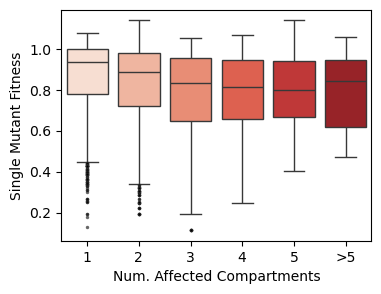

In [23]:
## Get fitness values
fitness_file = (
    pl
    .read_csv("/home/alex/alex_files/markerproject_redux/misc_files/strain_ids_and_single_mutant_fitness.csv")
    .select(["ORF", "Allele", "SMF_26C", "SMF_30C"])
    .with_columns(
        (
            pl
            .when(pl.col("Allele").is_null())
            .then(pl.lit(""))
            .otherwise(pl.col("Allele"))
        ).alias("Allele")
    )
)


mapping_files = (
    pl
    .read_csv("/home/alex/alex_files/markerproject_redux/array_mapping_files/*.csv")
    .drop(["Plate", "Row", "Column", "Strain_ID", "Allele"])
    .join(fitness_file, on=["ORF"], how="left")
    .unique()
    .with_columns(
        (
            pl
            .when(pl.col("Name").is_null())
            .then(pl.lit(""))
            .otherwise(pl.col("Name"))
        ).alias("Name")
        )
    )


## Get pleiotropy data
marker_dfs = []
for marker in markers:
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (pl.lit(marker).alias("Marker")),
            (pl.col("Overall_Penetrance") * 100)
            )
        .select(["Marker", "ORF", "Strain_ID",])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        )
    marker_dfs.append(marker_df)

combined_df = pl.concat(marker_dfs, how="vertical")

combined_df_plei = (
    combined_df
    .unique()
    .group_by(["Strain_ID",])
    .agg(pl.len().alias("Num_Comps"))
    .with_columns(
        (
            pl
            .when(pl.col("Num_Comps") > 5)
            .then(6)
            .otherwise(pl.col("Num_Comps"))
        ).alias("Num_Comps")
    )
)

combined_df = (
    combined_df
    .join(combined_df_plei, on="Strain_ID")
    )


## Join fitness and pleiotropy, choose the appropriate SMF for each strain
### DMA and TSA-37Cs get SMF_30C (strains weren't screened at 37C) while TSA-26Cs get SMF_26C
combined_df = (
    combined_df
    .join(mapping_files, on="ORF")
    .with_columns(
        (
            pl
            .when(pl.col("Strain_ID").str.contains("-26C"))
            .then(pl.col("SMF_26C"))
            .otherwise(pl.col("SMF_30C"))
        ).alias("SMF")
    )
    .drop(["SMF_26C", "SMF_30C"])
)


# Plot
fig, ax = plt.subplots(figsize=(4, 3))

flierprops = dict(
    marker='o',
    markersize=2,
    markerfacecolor='black',
    markeredgewidth=0.5,
    alpha=0.6
)

sns.boxplot(x="Num_Comps", y="SMF",
            hue="Num_Comps",
            palette=sns.color_palette("Reds", as_cmap=False),
            data=combined_df,
            legend=False,
            flierprops=flierprops)

# axis labels (rename axes)
ax.set_xticklabels([
    ">5" if tick.get_text() == "6" else tick.get_text()
    for tick in ax.get_xticklabels()
])

ax.set_xlabel("Num. Affected Compartments")
ax.set_ylabel("Single Mutant Fitness")

plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/pleifit.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()

### Bioprocess Enrichment

For BP enrichment, I'm using ShinyGO (https://bioinformatics.sdstate.edu/go74/). There's no way to script it, so I've been manually copying gene lists on their website and downloading the output. For background, I use sheetB strains and for query I use sheetD. I've done enrichment for all markers pooled together (single output) and for each marker individually (grid output).

In [51]:
## Read data
sheetB_dfs = []
sheetD_dfs = []
for marker in markers:
    sheetB = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetB")
        .select("ORF")
        )
    sheetB_dfs.append(sheetB)
    
    sheetD = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .select("ORF")
        )
    sheetD_dfs.append(sheetD)

combined_B = pl.concat(sheetB_dfs, how="vertical").unique()
combined_D = pl.concat(sheetD_dfs, how="vertical").unique()

In [ ]:
enrichment_results = (
    pl
    .read_csv(f"/home/alex/alex_files/markerproject_redux/functional_enrichment/{phenotype_set}/enrichments_up_to_mito.csv")
    .select(["Enrichment FDR", "Fold Enrichment", "Pathway"])
    .rename({"Enrichment FDR": "FDR"})
    .to_pandas()
)

# sort so most significant is at top
enrichment_results = enrichment_results.sort_values("FDR", ascending=True)

# convert FDR to -log10 for spacing
enrichment_results["logFDR"] = -np.log10(enrichment_results["FDR"])

plt.figure(figsize=(2, 10))

sns.scatterplot(
    data=enrichment_results,
    x="logFDR",
    y="Pathway",
    size="Fold Enrichment",
    sizes=(20, 200),   # controls bubble size range
    color="#093D5F",   # neutral color like your example
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("-log10(FDR)")
plt.ylabel("")

plt.grid(axis='x', linestyle='--', alpha=0.3)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/funenrich.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()

/tmp/ipykernel_15832/1773545657.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(
/tmp/ipykernel_15832/1773545657.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(
/tmp/ipykernel_15832/1773545657.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(
/tmp/ipykernel_15832/1773545657.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(
/tmp/ipykernel_15832/1773545657.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(
/tmp/ipykernel_15832/1773545657.py:91: UserWarning: set

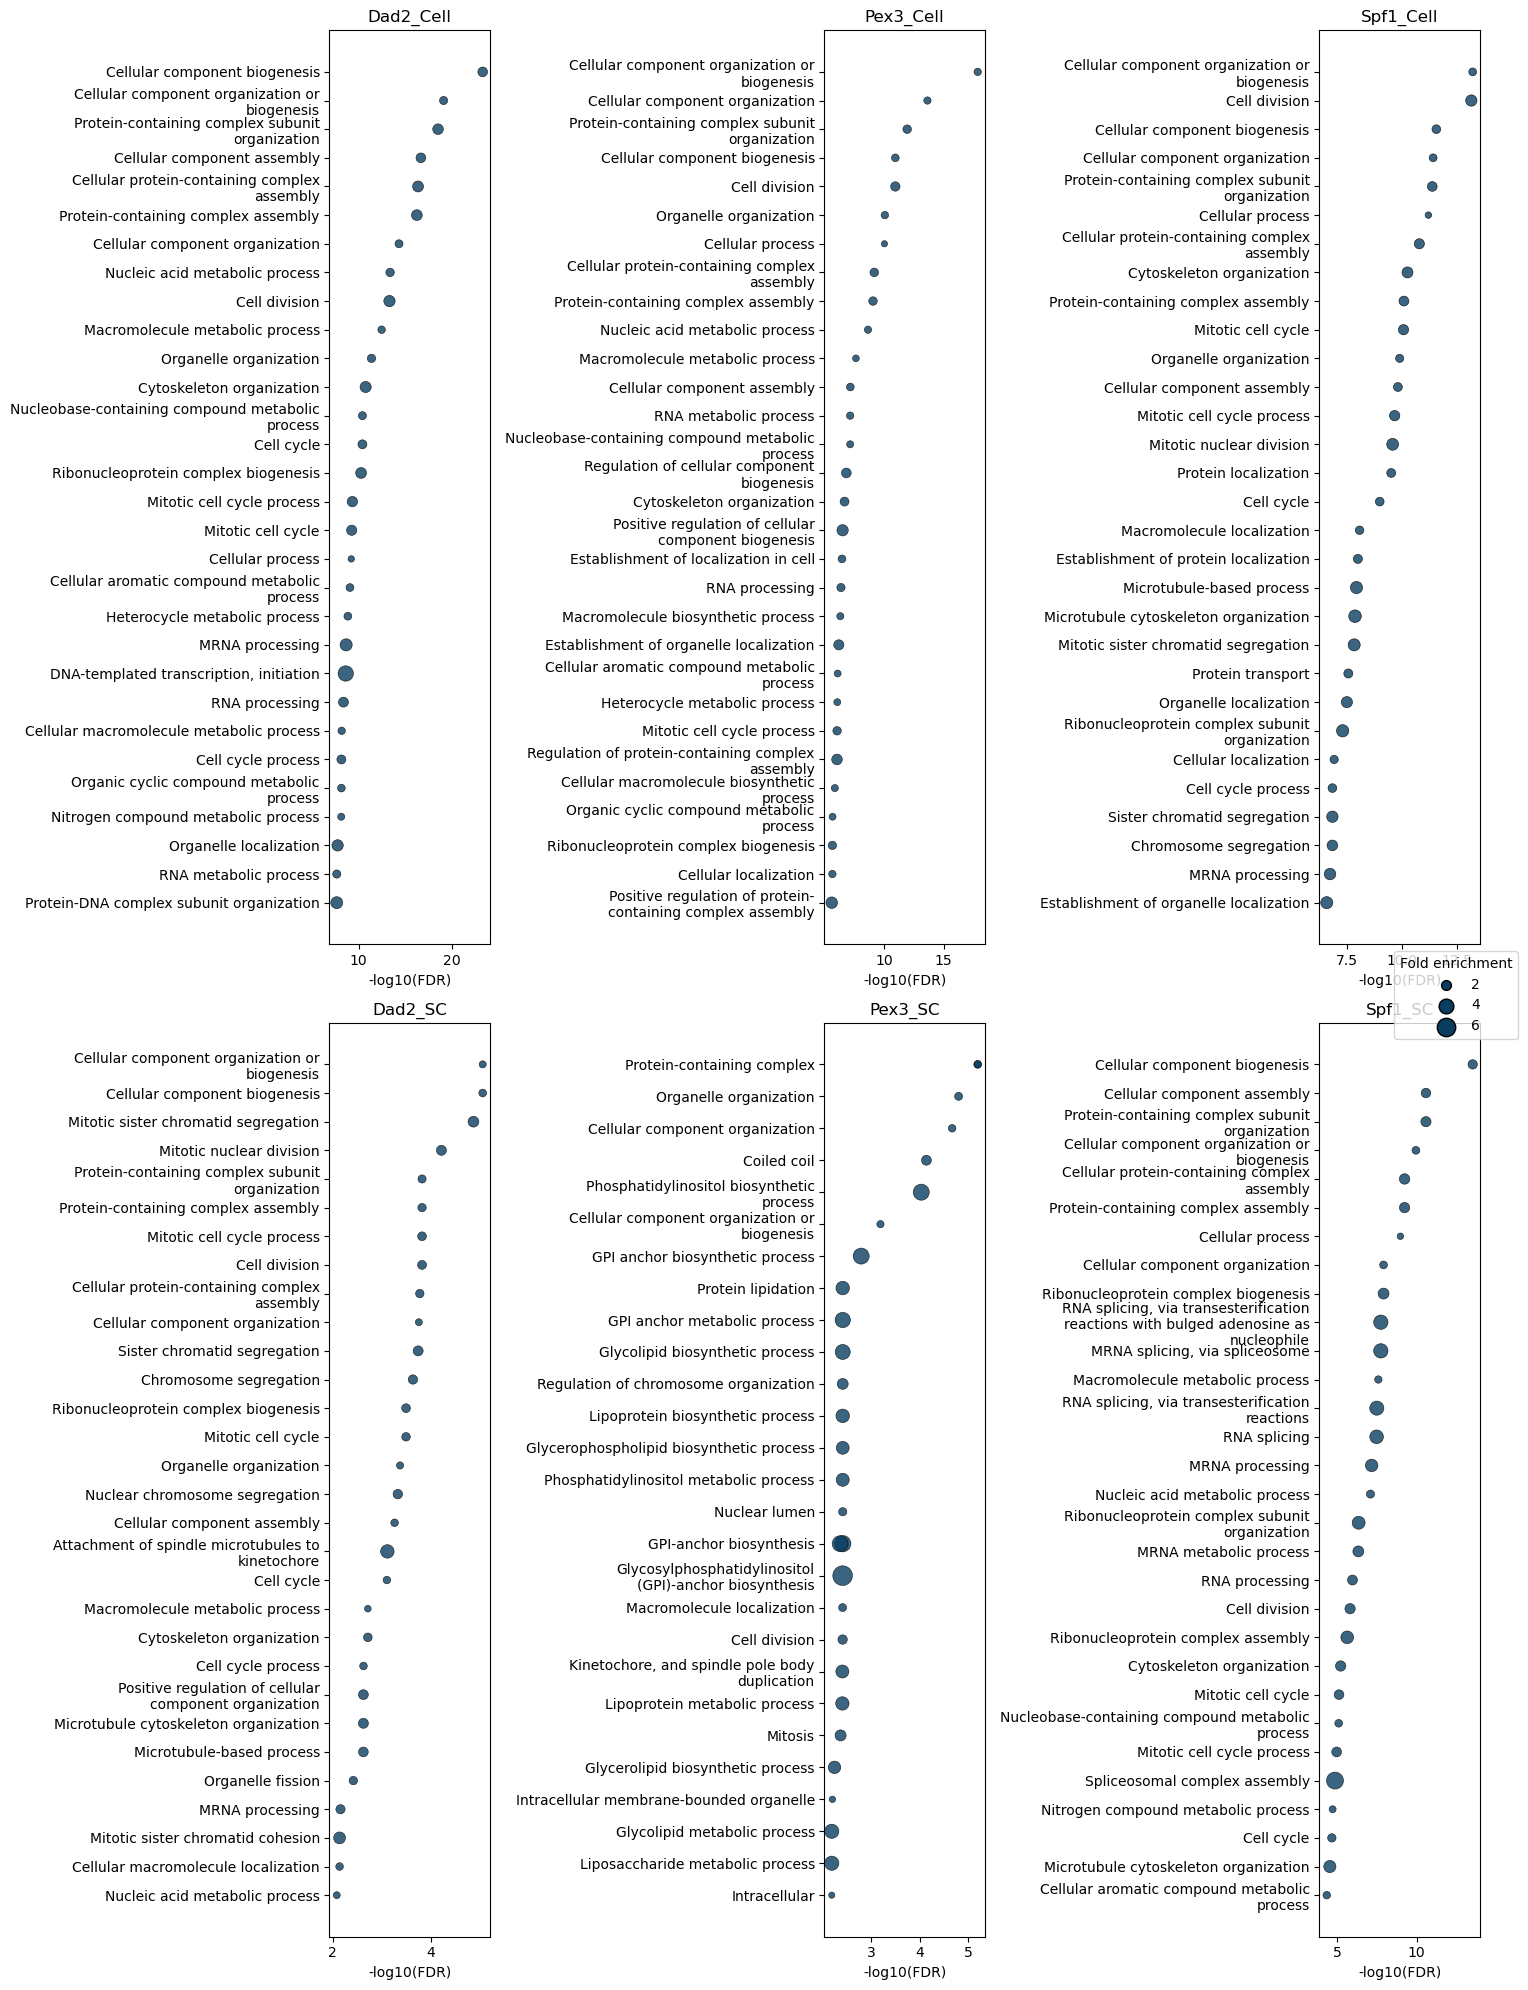

In [113]:
import textwrap
def wrap_labels(labels, width=7):
    return [textwrap.fill(label, width) for label in labels]

def size_map(val, vmin, vmax, smin=20, smax=200):
    return smin + (val - vmin) / (vmax - vmin) * (smax - smin)

# Load data
enrichment_dfs = {}
for marker in ["Dad2", "Pex3", "Spf1"]:
    
    ### CELL DATA
    marker_df_cell = (
        pl
        .read_csv(f"/home/alex/alex_files/markerproject_redux/functional_enrichment/Cells/{marker}_ShinyGO_enrichments.csv")
        .select(["Enrichment FDR", "Fold Enrichment", "Pathway"])
        .rename({"Enrichment FDR": "FDR"})
        .to_pandas()
    )
    
    # sort so most significant is at top
    marker_df_cell = marker_df_cell.sort_values("FDR", ascending=True)

    # convert FDR to -log10 for spacing
    marker_df_cell["logFDR"] = -np.log10(marker_df_cell["FDR"])
    
    enrichment_dfs[f"{marker}_Cell"] = marker_df_cell
    
    
    ### SUBCELLULAR COMPARTMENT DATA
    marker_df_comp = (
        pl
        .read_csv(f"/home/alex/alex_files/markerproject_redux/functional_enrichment/Compartments/{marker}_ShinyGO_enrichments.csv")
        .select(["Enrichment FDR", "Fold Enrichment", "Pathway"])
        .rename({"Enrichment FDR": "FDR"})
        .to_pandas()
    )
    
    # sort so most significant is at top
    marker_df_comp = marker_df_comp.sort_values("FDR", ascending=True)

    # convert FDR to -log10 for spacing
    marker_df_comp["logFDR"] = -np.log10(marker_df_comp["FDR"])
    
    enrichment_dfs[f"{marker}_SC"] = marker_df_comp


# Create subplot grid
n = len(enrichment_dfs)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 20), sharex=False)
axes = axes.flatten()

# Determine values for generalizing fold enrichment scaling
all_vals = pd.concat(enrichment_dfs.values())["Fold Enrichment"]

size_min = all_vals.min()
size_max = all_vals.max()
#size_max = np.percentile(all_vals, 90)

size_norm = mcolors.Normalize(vmin=size_min, vmax=size_max)

# Plot enrichments for each marker
panel_order = [
    "Dad2_Cell",
    "Pex3_Cell",
    "Spf1_Cell",
    "Dad2_SC",
    "Pex3_SC",
    "Spf1_SC"
]
for ax, name in zip(axes, panel_order):
    
    df = enrichment_dfs[name]
    
    sns.scatterplot(
        data=df,
        x="logFDR",
        y="Pathway",
        size="Fold Enrichment",
        sizes=(20, 200),
        size_norm=size_norm,
        color="#093D5F",
        edgecolor="black",
        alpha=0.8,
        ax=ax
    )
    
    ax.set_yticklabels(
    wrap_labels([t.get_text() for t in ax.get_yticklabels()], 40)
    )

    plt.subplots_adjust(left=0.3)
    
    ax.set_title(name)
    ax.set_xlabel("-log10(FDR)")
    ax.set_ylabel("")
    
    if ax.legend_:
        ax.legend_.remove()
    
# Clean unused panels
for i in range(len(enrichment_dfs), len(axes)):
    axes[i].axis("off")


legend_vals = [2, 4, 6]  # adjust to your data
handles = [
    plt.scatter(
        [], [], 
        s=size_map(v, size_min, size_max),
        color="#093D5F",
        edgecolor="black"
    )
    for v in legend_vals
]

fig.legend(
    handles,
    [str(v) for v in legend_vals],
    title="Fold enrichment",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5)
)

plt.subplots_adjust(right=1)

plt.tight_layout()
plt.savefig("/mnt/c/Users/peree/OneDrive/Desktop/funenrich2.pdf", format="pdf",  bbox_inches="tight")
plt.show()
plt.close()